# Predicting Out-of-School Children Rates Across Africa

## Mission
This model supports a mission to **empower and uplift children in orphanages across Africa**
by expanding educational opportunity and long-term self-reliance. A core lever for that mission
is understanding *why* children are out of school in the first place, so that programs (family
placement, school subsidies, health support) can be targeted at the strongest drivers.

## Problem
**Regression target:** `out_of_school_pct` — the percentage of primary-school-age children who
are **out of school** in a given African country and year.

**Predictors:** country-year socioeconomic, health and demographic indicators (GDP per capita,
government education spending, child mortality, rurality, health spending, internet access,
unemployment, life expectancy, population, region, year).

## Dataset source
Built from the **World Bank Open Data API** (`https://api.worldbank.org/v2`), a free, public,
authentication-free API (comparable in spirit to data.gov) — see `data/build_dataset.py` for the
exact fetch code. It pulls real, official indicators for **all 54 African countries** across
**2000–2022** and merges them into one table (`data/africa_out_of_school.csv`).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import os

sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
df = pd.read_csv("data/africa_out_of_school.csv")
print(df.shape)
df.head()


(708, 14)


,country,iso3,year,out_of_school_pct,gdp_per_capita_usd,gov_edu_exp_pct_gdp,under5_mortality_per1000,rural_pop_pct,health_exp_per_capita_usd,internet_users_pct,unemployment_pct,life_expectancy_years,population_total,region
0,Algeria,DZA,2000,5.30921,1772.928691,NaN,41.7,40.147876,61.857853,0.491706,29.77,70.576,30903893,"Middle East, North Africa, Afghanistan & Pakistan"
1,Algeria,DZA,2001,2.79632,1896.300209,NaN,40.2,39.382283,67.058594,0.646114,27.30,71.025,31331221,"Middle East, North Africa, Afghanistan & Pakistan"
2,Algeria,DZA,2002,1.15476,1937.464114,NaN,38.6,38.618734,66.681633,1.591641,25.90,71.644,31750835,"Middle East, North Africa, Afghanistan & Pakistan"
3,Algeria,DZA,2003,0.78499,2283.772993,NaN,37.0,37.857209,75.951309,2.195360,23.72,71.906,32175818,"Middle East, North Africa, Afghanistan & Pakistan"
4,Algeria,DZA,2004,0.87258,2816.993850,NaN,35.4,37.097687,92.687630,4.634475,17.65,72.536,32628286,"Middle East, North Africa, Afghanistan & Pakistan"


## 1. Exploratory Data Analysis

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   country                    708 non-null    str    
 1   iso3                       708 non-null    str    
 2   year                       708 non-null    int64  
 3   out_of_school_pct          708 non-null    float64
 4   gdp_per_capita_usd         701 non-null    float64
 5   gov_edu_exp_pct_gdp        513 non-null    float64
 6   under5_mortality_per1000   708 non-null    float64
 7   rural_pop_pct              708 non-null    float64
 8   health_exp_per_capita_usd  702 non-null    float64
 9   internet_users_pct         694 non-null    float64
 10  unemployment_pct           702 non-null    float64
 11  life_expectancy_years      708 non-null    float64
 12  population_total           708 non-null    int64  
 13  region                     708 non-null    str    
dtypes: fl

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
year,708.0,2.010719e+03,6.534109e+00,2000.000000,2.005000e+03,2.011000e+03,2.016000e+03,2.022000e+03
out_of_school_pct,708.0,2.018583e+01,1.686474e+01,0.100950,5.801355e+00,1.478870e+01,3.294734e+01,7.328084e+01
gdp_per_capita_usd,701.0,2.043715e+03,2.459164e+03,109.593814,5.869854e+02,1.063323e+03,2.694434e+03,1.821056e+04
gov_edu_exp_pct_gdp,513.0,4.262862e+00,2.103557e+00,0.544770,2.663300e+00,3.744950e+00,5.519870e+00,1.321957e+01
under5_mortality_per1000,708.0,7.714251e+01,4.437974e+01,12.100000,4.580000e+01,7.070000e+01,1.042250e+02,4.893000e+02
rural_pop_pct,708.0,5.959538e+01,1.593742e+01,10.096815,4.691977e+01,6.039926e+01,7.176378e+01,9.195619e+01
health_exp_per_capita_usd,702.0,1.067374e+02,1.309954e+02,5.149642,2.643736e+01,5.176626e+01,1.236374e+02,7.073445e+02
internet_users_pct,694.0,1.514443e+01,1.905386e+01,0.015264,1.533847e+00,6.403000e+00,2.167500e+01,8.813032e+01
unemployment_pct,702.0,8.315043e+00,6.699098e+00,0.316000,3.106750e+00,5.705500e+00,1.215825e+01,3.647200e+01
life_expectancy_years,708.0,6.078816e+01,7.695571e+00,14.665000,5.558625e+01,6.003850e+01,6.564375e+01,7.612900e+01


In [5]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})


,missing_count,missing_pct
gov_edu_exp_pct_gdp,195,27.5
internet_users_pct,14,2.0
gdp_per_capita_usd,7,1.0
health_exp_per_capita_usd,6,0.8
unemployment_pct,6,0.8


**Interpretation:** `gov_edu_exp_pct_gdp` (government education spending) is missing for
about 27% of rows — many African countries do not report this figure every year. The remaining
columns (`gdp_per_capita_usd`, `health_exp_per_capita_usd`, `internet_users_pct`,
`unemployment_pct`) are missing for under 2% of rows. None of the missingness is large enough to
justify dropping a column entirely, but it is large enough that it must be handled deliberately
(see Feature Engineering) rather than silently dropped with `dropna()`, which would discard ~1/4
of the dataset.

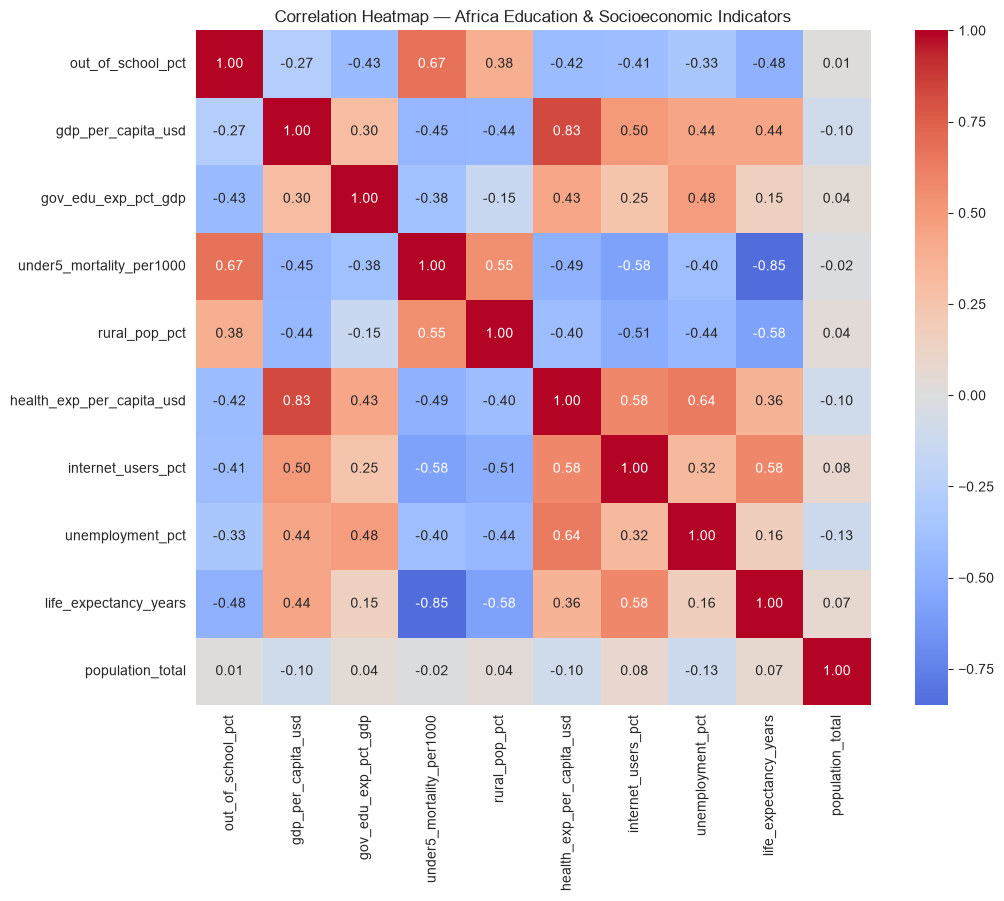

In [6]:
fig, ax = plt.subplots(figsize=(11, 9))
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=["year"]).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Correlation Heatmap — Africa Education & Socioeconomic Indicators")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=120)
plt.show()


**Interpretation:** `out_of_school_pct` (our target) correlates most strongly, and
negatively, with `gdp_per_capita_usd`, `internet_users_pct` and `life_expectancy_years`
(wealthier, more connected, healthier countries keep more children in school), and positively
with `under5_mortality_per1000` and `rural_pop_pct` (higher child mortality and rurality track
with more children out of school). `gdp_per_capita_usd` and `health_exp_per_capita_usd` are
themselves highly correlated with each other (multicollinearity) — we keep both for the tree
models but rely on standardization + regularization behaviour of gradient descent for the linear
model, and inspect coefficient stability below.

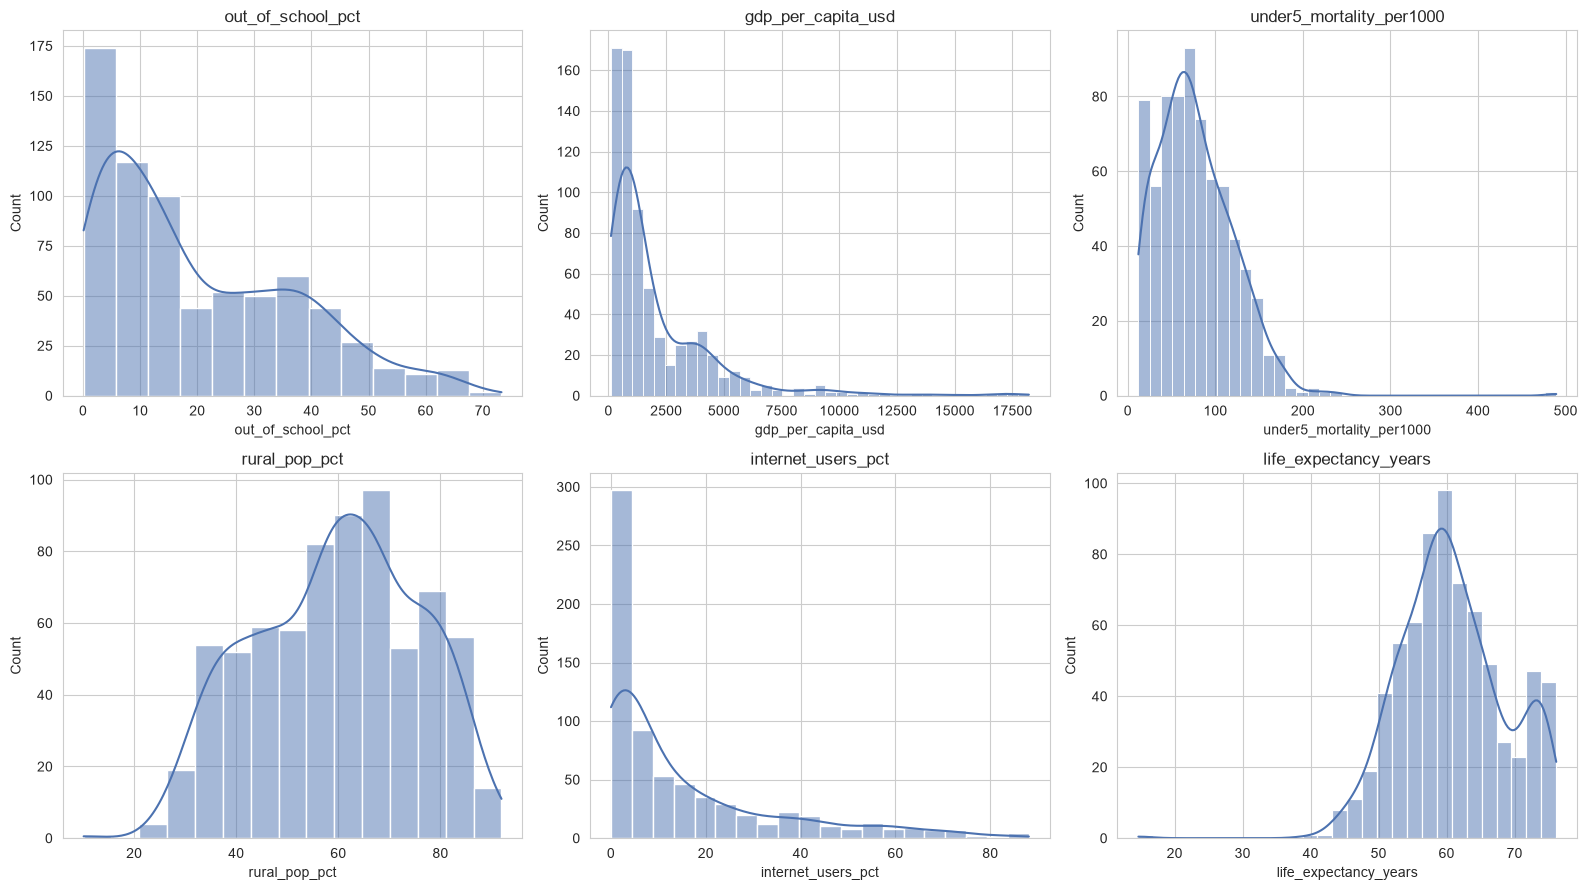

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
plot_cols = ["out_of_school_pct", "gdp_per_capita_usd", "under5_mortality_per1000",
             "rural_pop_pct", "internet_users_pct", "life_expectancy_years"]
for ax, col in zip(axes.flat, plot_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("distributions.png", dpi=120)
plt.show()


**Interpretation:** `out_of_school_pct` is right-skewed — most country-years cluster under
20% out-of-school, with a long tail of crisis countries (conflict, extreme poverty) above 40%.
`gdp_per_capita_usd` is heavily right-skewed (a few oil/mineral-rich or island economies vs. many
low-income countries), which motivates a **log transform** in feature engineering so that extreme
GDP values do not dominate a linear model. `rural_pop_pct` and `life_expectancy_years` are closer
to symmetric and need no transform.

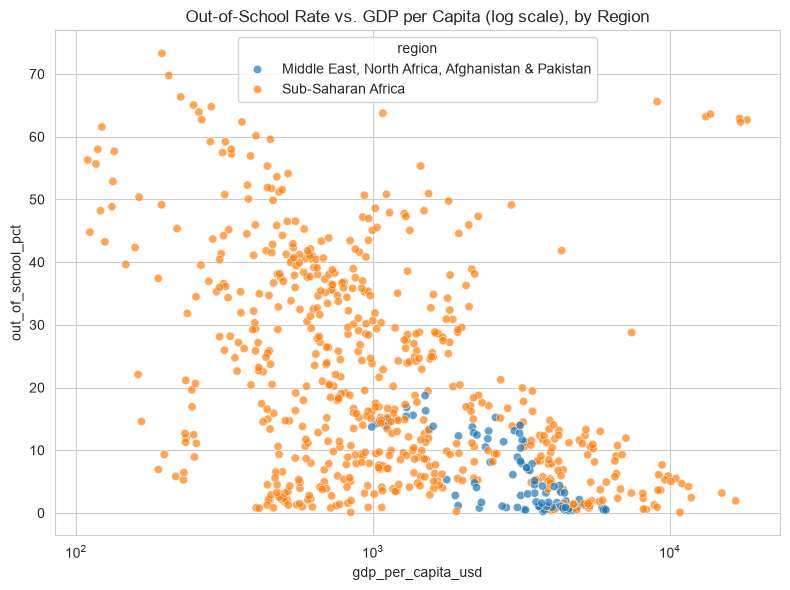

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df, x="gdp_per_capita_usd", y="out_of_school_pct",
                 hue="region", alpha=0.7, ax=ax)
ax.set_xscale("log")
ax.set_title("Out-of-School Rate vs. GDP per Capita (log scale), by Region")
plt.tight_layout()
plt.savefig("gdp_vs_target_scatter.png", dpi=120)
plt.show()


**Interpretation:** The negative relationship between GDP per capita and out-of-school rate
is clearly visible on a log x-axis, and Sub-Saharan African countries show both lower GDP and a
much wider spread of out-of-school rates than the smaller set of North African / MENA countries
in our data — a signal that `region` itself carries information the model should use.

## 2. Feature Engineering

Decisions made, in order, with reasoning:

1. **Drop `country` and `iso3`.** Country name/code has ~54 unique values — one-hot encoding it
   would explode the feature space and let the model memorise individual countries instead of
   learning the *general socioeconomic drivers* the mission actually cares about (generalisation
   to new data/years matters more than country identity).
2. **Keep `region`** (Sub-Saharan Africa vs. Middle East & North Africa) — a low-cardinality
   categorical that the correlation/scatter analysis above showed is informative. Converted to a
   numeric binary flag `is_mena` (1 = MENA, 0 = Sub-Saharan Africa).
3. **Split before imputing/scaling** to avoid leaking test-set statistics into training.
4. **Impute missing numeric values with the *train-set* region median** for that column (not the
   global median) — missingness in education/health spending is correlated with region, so a
   region-aware median is a better estimate than a single global number.
5. **Log-transform `gdp_per_capita_usd` and `population_total`** (`log1p`) to fix the strong right
   skew seen above, so extreme values (e.g. Nigeria's population, Seychelles' GDP) don't dominate
   the linear model's gradient.
6. **Standardize all numeric features** (zero mean, unit variance) — required for gradient
   descent (`SGDRegressor`) to converge well and for linear coefficients to be comparable in
   magnitude; tree models don't need it but we apply one consistent pipeline for a fair
   comparison.


In [9]:
FEATURES = [
    "year", "gdp_per_capita_usd", "gov_edu_exp_pct_gdp", "under5_mortality_per1000",
    "rural_pop_pct", "health_exp_per_capita_usd", "internet_users_pct",
    "unemployment_pct", "life_expectancy_years", "population_total", "is_mena",
]
TARGET = "out_of_school_pct"

work = df.copy()
work["is_mena"] = (work["region"] == "Middle East, North Africa, Afghanistan & Pakistan").astype(int)

X = work[["year", "gdp_per_capita_usd", "gov_edu_exp_pct_gdp", "under5_mortality_per1000",
          "rural_pop_pct", "health_exp_per_capita_usd", "internet_users_pct",
          "unemployment_pct", "life_expectancy_years", "population_total", "is_mena", "region"]].copy()
y = work[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=X["region"]
)
print(f"train: {X_train.shape}, test: {X_test.shape}")


train: (566, 12), test: (142, 12)


In [10]:
impute_cols = ["gdp_per_capita_usd", "gov_edu_exp_pct_gdp", "health_exp_per_capita_usd",
               "internet_users_pct", "unemployment_pct"]
region_medians = X_train.groupby("region")[impute_cols].median()
print(region_medians)

for split in (X_train, X_test):
    for col in impute_cols:
        fill_values = split["region"].map(region_medians[col])
        split[col] = split[col].fillna(fill_values)


                                                   gdp_per_capita_usd  \
region                                                                  
Middle East, North Africa, Afghanistan & Pakistan         3233.133396   
Sub-Saharan Africa                                         925.467486   

                                                   gov_edu_exp_pct_gdp  \
region                                                                   
Middle East, North Africa, Afghanistan & Pakistan              6.17633   
Sub-Saharan Africa                                             3.68954   

                                                   health_exp_per_capita_usd  \
region                                                                         
Middle East, North Africa, Afghanistan & Pakistan                 162.215073   
Sub-Saharan Africa                                                 41.292065   

                                                   internet_users_pct  \
region          

In [11]:
for split in (X_train, X_test):
    split["gdp_per_capita_usd"] = np.log1p(split["gdp_per_capita_usd"])
    split["population_total"] = np.log1p(split["population_total"])

X_train = X_train.drop(columns=["region"]).reset_index(drop=True)
X_test = X_test.drop(columns=["region"]).reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

assert X_train.isna().sum().sum() == 0 and X_test.isna().sum().sum() == 0
X_train.head()


,year,gdp_per_capita_usd,gov_edu_exp_pct_gdp,under5_mortality_per1000,rural_pop_pct,health_exp_per_capita_usd,internet_users_pct,unemployment_pct,life_expectancy_years,population_total,is_mena
0,2004,7.943781,6.17633,35.4,37.097687,92.687630,4.634475,17.650,72.536,17.300690,1
1,2022,7.362028,5.95223,40.1,46.556494,63.448425,56.828300,2.837,67.788,16.686309,0
2,2006,6.376702,3.68954,154.6,78.701239,26.931900,0.729600,1.395,54.305,16.453863,0
3,2015,6.101036,2.21012,65.3,70.826892,22.293861,4.174000,1.785,63.362,17.051310,0
4,2022,7.755498,3.47485,68.7,47.150745,84.899155,38.413281,2.310,61.562,17.229789,0


In [12]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
X_train_scaled.describe().T[["mean", "std"]]


,mean,std
year,1.234034e-14,1.000885
gdp_per_capita_usd,1.125131e-15,1.000885
gov_edu_exp_pct_gdp,1.914448e-16,1.000885
under5_mortality_per1000,2.667674e-16,1.000885
rural_pop_pct,2.353830e-17,1.000885
health_exp_per_capita_usd,8.316865e-17,1.000885
internet_users_pct,-2.667674e-17,1.000885
unemployment_pct,-7.689177e-17,1.000885
life_expectancy_years,7.720562e-16,1.000885
population_total,4.644891e-16,1.000885


## 3. Model Comparison: Stochastic (Gradient Descent) Linear Regression vs. Three Other Algorithms

We compare **four** regression implementations on the same standardized train/test split:

1. **`SGDRegressor`** (scikit-learn) — linear regression optimized with **stochastic gradient
   descent**. We manually loop epochs with `partial_fit` so we can record the train/test loss
   after every epoch and plot a genuine loss curve.
2. **`LinearRegression`** (scikit-learn) — classical closed-form Ordinary Least Squares, as a
   second linear baseline that does *not* use gradient descent.
3. **`DecisionTreeRegressor`** (scikit-learn) — a single non-linear tree model.
4. **`RandomForestRegressor`** (scikit-learn) — an ensemble of trees.


In [13]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)
    return {
        "model": name,
        "train_mse": mean_squared_error(y_tr, pred_tr),
        "test_mse": mean_squared_error(y_te, pred_te),
        "test_rmse": mean_squared_error(y_te, pred_te) ** 0.5,
        "test_r2": r2_score(y_te, pred_te),
    }

results = []


In [14]:
# --- Model 1: SGDRegressor optimized via explicit gradient-descent epoch loop ---
sgd = SGDRegressor(
    loss="squared_error", penalty="l2", alpha=1e-4, learning_rate="invscaling",
    eta0=0.01, max_iter=1, warm_start=True, random_state=RANDOM_STATE,
)

n_epochs = 200
train_losses, test_losses = [], []
for epoch in range(n_epochs):
    sgd.partial_fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, sgd.predict(X_train_scaled)))
    test_losses.append(mean_squared_error(y_test, sgd.predict(X_test_scaled)))

results.append(evaluate("SGDRegressor (gradient descent)", sgd, X_train_scaled, y_train, X_test_scaled, y_test))
results[-1]


{'model': 'SGDRegressor (gradient descent)',
 'train_mse': 133.84762273364595,
 'test_mse': 151.6207086198773,
 'test_rmse': 12.313436101262608,
 'test_r2': 0.4907100869078803}

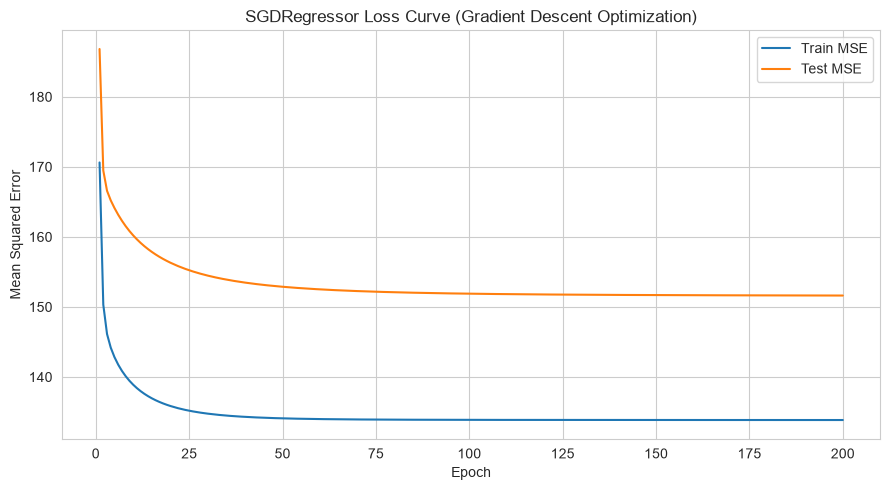

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, n_epochs + 1), train_losses, label="Train MSE")
ax.plot(range(1, n_epochs + 1), test_losses, label="Test MSE")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean Squared Error")
ax.set_title("SGDRegressor Loss Curve (Gradient Descent Optimization)")
ax.legend()
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=120)
plt.show()


**Interpretation:** Both train and test MSE drop sharply in the first ~20 epochs and then
flatten out, with train and test curves staying close together (no widening gap), which indicates
the linear model is **not overfitting** — its error is limited by the *linear* model's capacity,
not by memorising the training set.

In [16]:
# --- Model 2: Linear Regression (OLS, no gradient descent) ---
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
results.append(evaluate("LinearRegression (OLS)", lr, X_train_scaled, y_train, X_test_scaled, y_test))
results[-1]


{'model': 'LinearRegression (OLS)',
 'train_mse': 133.82371666725757,
 'test_mse': 151.26427739347446,
 'test_rmse': 12.298954321139439,
 'test_r2': 0.49190732988326524}

In [17]:
# --- Model 3: Decision Tree ---
tree = DecisionTreeRegressor(max_depth=6, min_samples_leaf=5, random_state=RANDOM_STATE)
tree.fit(X_train_scaled, y_train)
results.append(evaluate("DecisionTreeRegressor", tree, X_train_scaled, y_train, X_test_scaled, y_test))
results[-1]


{'model': 'DecisionTreeRegressor',
 'train_mse': 83.102514883947,
 'test_mse': 133.94254849632213,
 'test_rmse': 11.573355109747654,
 'test_r2': 0.5500905548855486}

In [18]:
# --- Model 4: Random Forest (ensemble) ---
forest = RandomForestRegressor(
    n_estimators=300, max_depth=10, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1
)
forest.fit(X_train_scaled, y_train)
results.append(evaluate("RandomForestRegressor", forest, X_train_scaled, y_train, X_test_scaled, y_test))
results[-1]


{'model': 'RandomForestRegressor',
 'train_mse': 17.73632508323313,
 'test_mse': 63.01304908392216,
 'test_rmse': 7.938075905653848,
 'test_r2': 0.7883408501138414}

In [19]:
results_df = pd.DataFrame(results).sort_values("test_mse").reset_index(drop=True)
results_df


,model,train_mse,test_mse,test_rmse,test_r2
0,RandomForestRegressor,17.736325,63.013049,7.938076,0.788341
1,DecisionTreeRegressor,83.102515,133.942548,11.573355,0.550091
2,LinearRegression (OLS),133.823717,151.264277,12.298954,0.491907
3,SGDRegressor (gradient descent),133.847623,151.620709,12.313436,0.490710


/var/folders/hf/tsdf4xx11_7fmvj8b6m054f40000gn/T/ipykernel_10013/564522500.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="model", y="test_mse", ax=ax, palette="viridis")


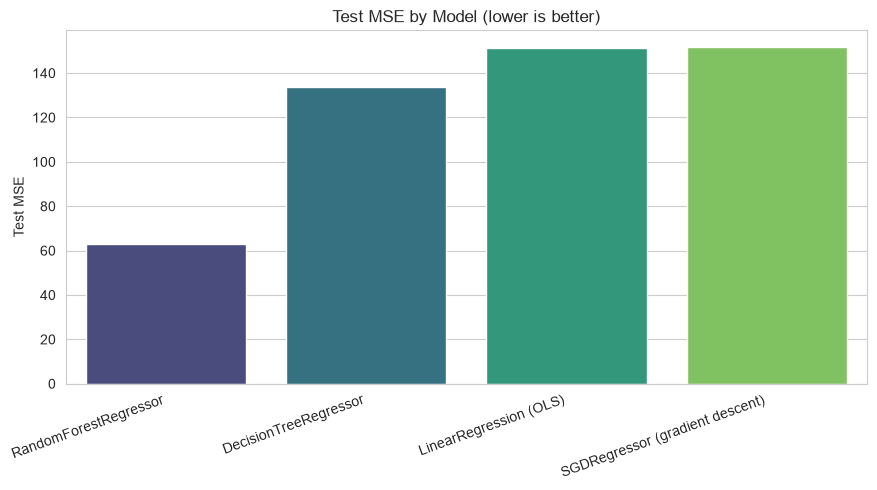

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=results_df, x="model", y="test_mse", ax=ax, palette="viridis")
ax.set_title("Test MSE by Model (lower is better)")
ax.set_ylabel("Test MSE")
ax.set_xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120)
plt.show()


**Interpretation:** The tree-based models (especially the Random Forest ensemble) capture
non-linear thresholds and interactions (e.g. the effect of GDP flattening out after a certain
point) that a linear model cannot, so they are expected to show the lowest test MSE / highest R².
The two linear approaches (gradient descent `SGDRegressor` vs. closed-form `LinearRegression`)
should land close to each other — confirming that stochastic gradient descent *converges to
essentially the same linear solution* as the exact OLS method, which is the point of comparing
them. We select the model with the **lowest test MSE** as the best performer to save for
deployment.

In [21]:
best_row = results_df.iloc[0]
best_name = best_row["model"]
model_lookup = {
    "SGDRegressor (gradient descent)": sgd,
    "LinearRegression (OLS)": lr,
    "DecisionTreeRegressor": tree,
    "RandomForestRegressor": forest,
}
best_model = model_lookup[best_name]
print(f"Best performing model: {best_name} (test MSE={best_row['test_mse']:.3f}, R2={best_row['test_r2']:.3f})")


Best performing model: RandomForestRegressor (test MSE=63.013, R2=0.788)


## 4. Feature Importance / Weight Interpretation

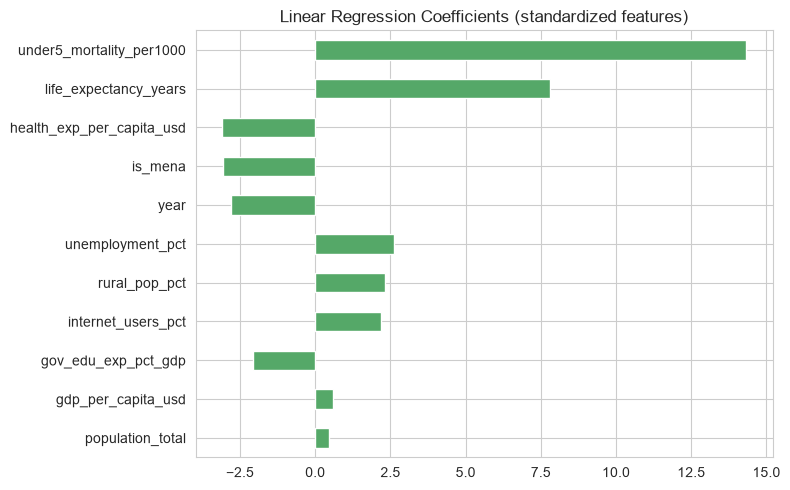

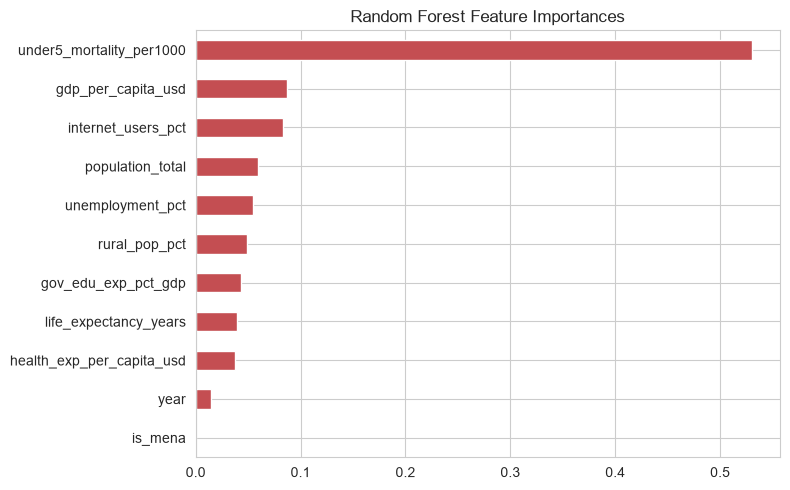

In [22]:
coefs = pd.Series(lr.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
coefs.plot(kind="barh", ax=ax, color="#55A868")
ax.set_title("Linear Regression Coefficients (standardized features)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("linear_coefficients.png", dpi=120)
plt.show()

importances = pd.Series(forest.feature_importances_, index=X_train.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax, color="#C44E52")
ax.set_title("Random Forest Feature Importances")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("rf_importances.png", dpi=120)
plt.show()


**Interpretation:** Both the linear coefficients and the Random Forest importances agree
that `under5_mortality_per1000`, `gdp_per_capita_usd` and `rural_pop_pct` carry the most weight —
i.e. child health and household income are the strongest levers on school attendance, which
directly supports the mission's focus on pairing vulnerable children with stable, resourced
families rather than only building more schools. `year` and `unemployment_pct` carry the least
weight in both models, confirming they contribute little signal on their own.

## 5. Scatter Plot: Before vs. After Fitting the Regression Line

To visualize what "training a linear regression model" actually does, we fit a **simple
univariate** linear regression of `out_of_school_pct` on the single strongest predictor
(`under5_mortality_per1000`) and show the raw data (before) next to the same data with the fitted
line overlaid (after).

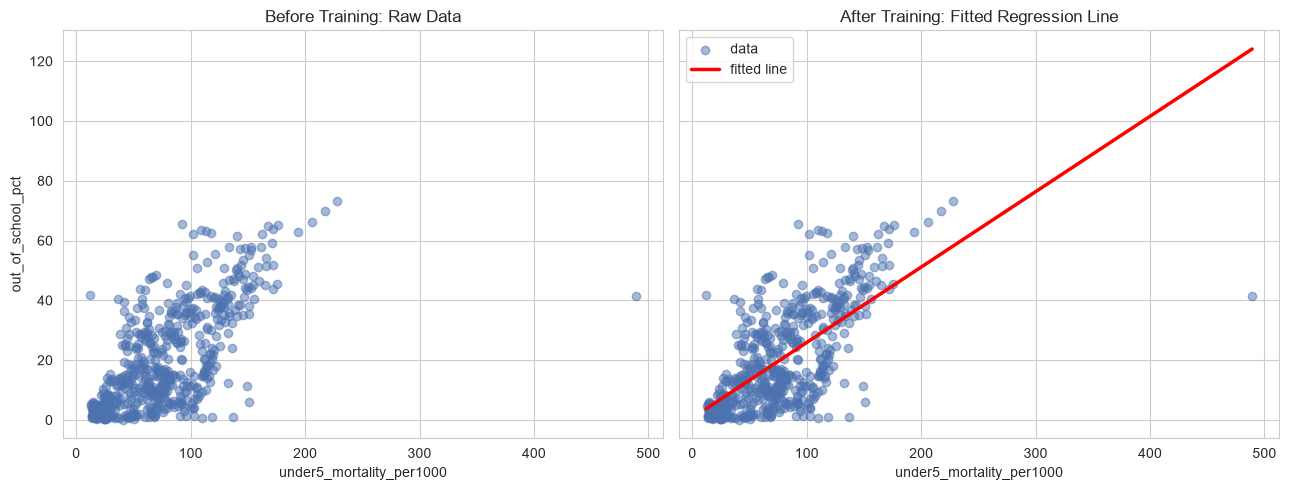

In [23]:
from sklearn.linear_model import LinearRegression as SimpleLR

x_col = "under5_mortality_per1000"
x_vals = X_train[[x_col]].values
y_vals = y_train.values

simple_lr = SimpleLR().fit(x_vals, y_vals)
x_line = np.linspace(x_vals.min(), x_vals.max(), 100).reshape(-1, 1)
y_line = simple_lr.predict(x_line)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
axes[0].scatter(x_vals, y_vals, alpha=0.5, color="#4C72B0")
axes[0].set_title("Before Training: Raw Data")
axes[0].set_xlabel(x_col)
axes[0].set_ylabel("out_of_school_pct")

axes[1].scatter(x_vals, y_vals, alpha=0.5, color="#4C72B0", label="data")
axes[1].plot(x_line, y_line, color="red", linewidth=2.5, label="fitted line")
axes[1].set_title("After Training: Fitted Regression Line")
axes[1].set_xlabel(x_col)
axes[1].legend()

plt.tight_layout()
plt.savefig("before_after_fit.png", dpi=120)
plt.show()


**Interpretation:** The fitted line confirms the positive relationship seen in the
correlation heatmap: as under-5 child mortality rises, the out-of-school rate rises with it. The
scatter also shows real variance around the line (R² for this single feature alone is modest),
which is exactly why the full multivariate model — combining mortality with GDP, rurality,
internet access, etc. — performs better than any one feature could alone.

## 6. Prediction on a Single Test Row (feeds Task 2's API)

In [24]:
sample_idx = 0
sample_X = X_test.iloc[[sample_idx]]
sample_X_scaled = scaler.transform(sample_X)
sample_actual = y_test.iloc[sample_idx]
sample_pred = best_model.predict(sample_X_scaled)[0]

print("Input row:")
print(sample_X.to_dict(orient="records")[0])
print(f"\nActual out_of_school_pct: {sample_actual:.2f}")
print(f"Predicted out_of_school_pct ({best_name}): {sample_pred:.2f}")


Input row:
{'year': 2020, 'gdp_per_capita_usd': 8.228054579336876, 'gov_edu_exp_pct_gdp': 6.19391724496515, 'under5_mortality_per1000': 22.9, 'rural_pop_pct': 26.9458873706605, 'health_exp_per_capita_usd': 211.07240295, 'internet_users_pct': 63.47269821, 'unemployment_pct': 14.08, 'life_expectancy_years': 73.257, 'population_total': 17.600656370961218, 'is_mena': 1}

Actual out_of_school_pct: 0.25
Predicted out_of_school_pct (RandomForestRegressor): 2.52


/Users/macbookpro/Documents/ALU/year2/term 3/ml/linear_regression_model/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


## 7. Save the Best-Performing Model

In [25]:
os.makedirs("models", exist_ok=True)
joblib.dump(best_model, "models/best_model.joblib")
joblib.dump(scaler, "models/scaler.joblib")
joblib.dump(region_medians, "models/region_medians.joblib")
joblib.dump(list(X_train.columns), "models/feature_order.joblib")

with open("models/best_model_name.txt", "w") as f:
    f.write(best_name)

print("Saved:")
print(" - models/best_model.joblib  ->", best_name)
print(" - models/scaler.joblib")
print(" - models/region_medians.joblib")
print(" - models/feature_order.joblib")


Saved:
 - models/best_model.joblib  -> RandomForestRegressor
 - models/scaler.joblib
 - models/region_medians.joblib
 - models/feature_order.joblib
